# Needed Packages

In [ ]:
#General imports
import os
import copy
import time
import fnmatch
import subprocess
import nglview as ngl
from invoke import run
from collections import Counter
from contextlib import redirect_stdout
from pathlib import Path
import math


#Mathematical imports
import numpy as np
from numpy import array, linspace
import pandas as pd
import matplotlib as plt
import matplotlib.pyplot as plt


#Import from ase
import ase
from ase import units
from ase import Atoms
from ase.io import read, write
from ase.units import Rydberg, Bohr
from ase.units import _amu
from ase.io.trajectory import Trajectory
from ase.build import bulk
from ase.build import surface
from ase.optimize import BFGS
from ase.visualize import view
from ase.filters import FrechetCellFilter
from ase.constraints import FixAtoms

from pyace import PyACECalculator

import elastic
from elastic import get_pressure, BMEOS, get_strain
from elastic import get_elementary_deformations, scan_volumes
from elastic import get_BM_EOS, get_elastic_tensor

from pymatgen.analysis.phase_diagram import PDEntry
from pymatgen.core.structure import Structure
from pymatgen.analysis.phase_diagram import PhaseDiagram
from pymatgen.symmetry.analyzer import SpacegroupAnalyzer
from pymatgen.analysis.phase_diagram import PDPlotter
from pymatgen.io.ase import AseAtomsAdaptor
from mp_api.client import MPRester
from pymatgen.core import Structure
from pymatgen.core.surface import SlabGenerator

import phonopy

In [6]:
%load_ext autoreload
%autoreload 2
from pot_functions import *
from pw_functions import *
from phonon_functions import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [12]:
ref_energies = {
    'Li' : -14.221146 * Rydberg,
    'O' : -31.581697 * Rydberg,  
}


pot_path = '/ccc160/akirsan/PhD/MLP/Li2O/train/train-O2/train-O2-own/train-O2-own-1/kappa-1400/0.1'
pot_name = pot_path.replace("ccc160/akirsan/PhD/MLP/Li2O/train/", "")
analysis_path = os.path.join(pot_path, "analysis")
#run(f"mkdir {analysis_path}")
#strucs_all = pd.read_pickle(os.path.join(pot_path, "alldata.pckl.gzip"), compression="gzip")

calc = PyACECalculator(os.path.join(pot_path,"output_potential.yaml"))
calc.set_active_set((os.path.join(pot_path,"output_potential.asi")))
set_calculator(calc)

Ry_bohr3_to_GPa = 1.47108 *10 **4


# PW Sample input data and PPs

In [4]:
input_data = {
                    'calculation' : 'scf',
                    'restart_mode' : 'from_scratch',
                    'pseudo_dir' : '/ccc160/bmeyer/pot.pwscf/',
                    'outdir' : './',
                    'prefix' : f"deform_{i}",
                    'tstress' : True,
                    'etot_conv_thr' : 1.e-5,
                    'tprnfor' : True,
                    'forc_conv_thr' : 1.e-5,
                    'ecutwfc' :30.0,
                    'ecutrho' :120.0,
                    'occupations' : 'smearing',
                    'mixing_mode' : 'plain',
                    'smearing' : 'gauss',
                    'degauss' : 0.01,
                    'vdw_corr' : 'D3-ext',
                    'london_rcut' : 100,
                    'diagonalization' : 'david',
                    'electron_maxstep' : 300,
                    'conv_thr' :1.0e-8,
                    'mixing_beta' : 0.5,
                    'kpts' : (8, 8, 4),
                    'koffset' : (0, 0, 0),
}
pseudopotentials = {
                    'Li' : 'Li-semi.uspp736-rev2.pbe.UPF',
                    'O' : 'O.uspp736.pbe.UPF'
}    

a


# Reference values

In [620]:
#in kJ/mol
ref_Ef = {
    'Li2O-solid' : -598.73,
    'Li2O2-solid' : -632.62,
}

#in GPa
ref_PBE_D3mod_elast = {
            'Li2O' : {
                        'c11' : 204.35,
                        'c12' : 19.80,
                        'c44' : 58.21,
                        'c13' : 0,
                        'c33' : 0,
                        'B' : 81.32,
                        'G' : 71.83,
                        'E' : 166.49,
                        'v' : 0.158
            },
    
            'Li2O2' : { 'c11' : 	 174.53,
                        'c33' :	     350.01,
                        'c12' : 	 48.03,
                        'c13' : 	 9.03,
                        'c44' : 	 40.94,
                        'B' : 	     87.69,
                        'G' : 0,
                        'E' : 0,
                        'v' : 0
                      },
}


ref_lit = {
    'Li2O2' : {
            'source' : 'https://doi.org/10.1080/14786430701286239',
            'method' : 'LDA',
            'alat' : { 'a' : 3.1817, 'c' : 7.6739 },
            'elast_const' : { 
                        'c11' : 207.3,
                        'c12' : 33.8,
                        'c13' : 21.5,
                        'c33' : 358.1,
                        'c44' : 46.4,
                        'B' : 98.0,
                        'G' : 0,
                        'E' : 0,
                        'v' : 0
                        },
}
}



In [ ]:

with MPRester('1rrCd5o3r69gbghUDV5fFzuncBdu1uVF') as mpr:
    docs_LiO = mpr.materials.summary.search(
        chemsys=["Li-O"],
        fields=["material_id","structure","composition",'formula_pretty','energy_per_atom']
    )
    li_docs = mpr.materials.summary.search(
        chemsys=["Li"],
        fields=[
            "material_id",
            "structure",
            "composition",
            "formula_pretty",
            "energy_per_atom",
        ]
    )

    # Elemental O
    o_docs = mpr.materials.summary.search(
        chemsys=["O"],
        fields=[
            "material_id",
            "structure",
            "composition",
            "formula_pretty",
            "energy_per_atom",
        ]
    )
docs = docs_LiO.copy()
docs.extend(li_docs)
docs.extend(o_docs)

# Create test structure dict

## Load and optimize test structures

In [4]:
set_calculator(calc)
Li2O_bulk = Atoms(symbols='Li8O4',
            scaled_positions=[    
                    [0.25000000,   0.25000000,   0.75000000],
                    [0.25000000,   0.75000000,   0.75000000],
                    [0.25000000,   0.75000000,   0.25000000],
                    [0.25000000,   0.25000000,   0.25000000],
                    [0.75000000,   0.25000000,   0.25000000],
                    [0.75000000,   0.75000000,   0.25000000],
                    [0.75000000,   0.75000000,   0.75000000],
                    [0.75000000,   0.25000000,   0.75000000],
                    [0.00000000,   0.00000000,   0.00000000],
                    [0.00000000,   0.50000000,   0.50000000],
                    [0.50000000,   0.00000000,   0.50000000],
                    [0.50000000,   0.50000000,   0.00000000]
                ],
            cell=[[4.608, 0.00, 0.00],
                    [0.00, 4.608, 0.00],
                    [0.00, 0.00, 4.608]],
            pbc=True,
            info={'n_units':4},
            calculator = calc)

Li_bcc_bulk = Atoms(symbols='Li2',
            scaled_positions=[    
                    [0.00000000,   0.00000000,   0.00000000],
                    [0.50000000,   0.50000000,   0.50000000]
                ],
            cell=[[3.425, 0.00, 0.00],
                    [0.00, 3.425, 0.00],
                    [0.00, 0.00, 3.425]],
            pbc=True,
            info={'n_units':2},
            calculator = calc
                   )

Li_fcc_bulk = Atoms(symbols='Li3',
            scaled_positions=[    
                    [0.00000000,   0.00000000,   0.00000000],
                    [0.50000000,   0.50000000,   0.00000000],
                    [0.00000000,   0.50000000,   0.50000000]
                ],
            cell=[[4.305, 0.00, 0.00],
                    [0.00, 4.305, 0.00],
                    [0.00, 0.00, 4.305]],
            pbc=True,
            info={'n_units':3},
            calculator = calc
                   )




a_Li2O2=3.1431 # in Angstrom
Li2O2_bulk = Atoms(symbols='Li4O4',
            scaled_positions=
                   [ 
                     [0.00000000, 0.00000000, 0.50000000],
                     [0.00000000, 0.00000000, 0.00000000],
                     [0.66666738, 0.33333476, 0.75      ],
                     [0.33333262, 0.66666524, 0.25      ],
                     [0.66666744, 0.33333487, 0.14861931],
                     [0.33333256, 0.66666513, 0.64861931],
                     [0.33333256, 0.66666513, 0.85138069],
                     [0.66666744, 0.33333487, 0.35138069]
                   ],
             cell = [[a_Li2O2, 0, 0],
                    [-a_Li2O2/2, np.sqrt(3)*a_Li2O2/2, 0],
                    [0, 0, 2.433*a_Li2O2]],
            pbc=True,
            info={'n_units':2},
            calculator = calc)





O2_molecule = Atoms(symbols='O2',
                    positions=[[10,10,10],[10,10,11.22]],
                    cell=[50,50,50],
                    pbc=True,
                    info={'n_units':2}, # needed because the energy per O atom makes calculating formation energies easier
                    calculator = calc)

BFGS(O2_molecule,logfile=None).run(fmax=0.0001) # optimize atomic positions
### MLP O2-molecule energy 
O2_energy = O2_molecule.get_potential_energy()
###


# all bulk structures in a list with a name. 
#opt_cell() optimizes the cell and positions

bulk_strucs = [['Li2O', opt_cell(Li2O_bulk, logfile=None)],
               ['Li_bcc', opt_cell(Li_bcc_bulk,logfile=None)],
               ['Li_fcc', opt_cell(Li_fcc_bulk,logfile=None)],
               ['Li2O2', opt_cell(Li2O2_bulk,logfile=None)]]


## Create dictionary with all important values

In [5]:
bulk_strucs_dict={}
for name, struc in bulk_strucs:
    bulk_strucs_dict[name]={
                            'ase_atoms' : struc, # ASE Atoms object of the optimized structures
                            'lattice' : lattice_ident(struc), # get lattice parameters and type
                            'elast_const' : calc_elast_const(struc), # get all the elastic constants
                            }


### Surfaces

In [86]:
set_calculator(calc)

######################
### for example hexagonal {h,k,i,l} miller-bravais indices 
### have to transformed to (h,k,l) miller indices
### for pymat SlabGenerator to read them
### via i= -(h+k) 
### 
### ex: 
### {0001} -->	(0,0,1)
### {1(-1)00} -->	(1,-1,0)
### {11(-2)0} -->	(1,1,0)
######################

cub_surfs = [ [1,0,0], [1,1,0], [1,1,1] ]
other_surfs = [ [0,0,1], [1,-1,0], [1,1,0] ]


for name,struc in bulk_strucs_dict.items(): 
    bulk_strucs_dict[name]['surfaces'] = {}
    print(name)
    if 'lattice' not in struc:
        continue
        
#    if bulk_strucs_dict[name]['lattice']['type'] == 'CUB':
#        for surf in cub_surfs:
#            key = f"{surf[0]}{surf[1]}{surf[2]}"
#            bulk_strucs_dict[name]['surfaces'][key] =  find_stable_surface( struc['ase_atoms'], surf[0],surf[1],surf[2], nrep=6)   

####  Works, but Li2O2 is bad for my mlp
    elif bulk_strucs_dict[name]['lattice']['type'] != 'CUB':
        for surf in other_surfs:
            key = f"{surf[0]}{surf[1]}{surf[2]}"
            bulk_strucs_dict[name]['surfaces'][key] =  find_stable_surface( struc['ase_atoms'], surf[0],surf[1],surf[2], nrep=3, opt=True)
    else:
        continue


        


Li2O
Li_bcc
Li_fcc
Li2O2
Low energy (0, 0, 1) surface found, starting geo-opt.
 (0, 0, 1) done !
Low energy (1, -1, 0) surface found, starting geo-opt.
 (1, -1, 0) done !
Low energy (1, 1, 0) surface found, starting geo-opt.
 (1, 1, 0) done !


In [99]:
#for name, key in bulk_strucs_dict['Li2O2']['surfaces'].items():
    #print(key['surface_energy'])

In [98]:
#view(bulk_strucs_dict['Li2O2']['surfaces']['1-10']['ase_atoms'].repeat((2,2,1)), viewer='ngl')

In [14]:
# Add gas phase molecules to your dictionary
bulk_strucs_dict['O2']={ 'ase_atoms' : O2_molecule}

### get bulk atomic reference energies and add formation energy to dict

In [15]:
# for formation energy calc
# its basically just your mlp energy divided by the number of units
# can also put in values by hand
# dict has to contain the elemental reference energies per atom
# in this case for example:
# Li => energy the mlp predicts for solid lithium per Li-atom
# O => energy the mlp predicts for an isolated O2 molecule per O-atom

set_calculator(calc)

ref_bulk_lmp = get_bulk_ref_e(bulk_strucs_dict)

# Add formation energies to your dictionary in kJ/mol (if your mlp works in eV)
for name in bulk_strucs_dict:
    bulk_strucs_dict[name]['Ef_kJ'] = get_formation_energy(bulk_strucs_dict[name]['ase_atoms'], ref_bulk_lmp)*96.485 # in kJ/mol
    

# Convex Hull

In [ ]:
prototype_dir = Path("/ccc160/akirsan/PhD/MLP/Li2O/ref-energies/AFLOW/aflow_prototype_encyclopedia/data")

AB2_dirs = sorted(
    p for p in prototype_dir.iterdir()
    if p.is_dir() and p.name.startswith("AB2_") # load all directory paths as PosixPath objects
)

AB2_strucs = {}

for directory in AB2_dirs:

    atoms_cif = directory / "aflow.cif" #  / "string" just adds string to the path

    if not atoms_cif.exists(): # check if aflow.cif exists in the dir
        continue

    atoms = read(atoms_cif)

    AB2_strucs[directory.name] = atoms

In [8]:
Li2O_strucs = {}
LiO2_strucs = {} 

for name, atoms in AB2_strucs.items():
    Li2O_strucs[name] = substitute_atoms(atoms, ["O", "Li"] )
    LiO2_strucs[name] = substitute_atoms(atoms, ["Li", "O"] )

In [147]:
input_data = {
                    'calculation' : 'scf',
                    'restart_mode' : 'from_scratch',
                    'pseudo_dir' : '/ccc160/bmeyer/pot.pwscf/',
                    'outdir' : './',
                    'prefix' : f"deform_{i}",
                    'tstress' : True,
                    'etot_conv_thr' : 1.e-5,
                    'tprnfor' : True,
                    'forc_conv_thr' : 1.e-5,
                    'ecutwfc' :30.0,
                    'ecutrho' :120.0,
                    'occupations' : 'smearing',
                    'mixing_mode' : 'plain',
                    'smearing' : 'gauss',
                    'degauss' : 0.01,
                    'vdw_corr' : 'D3-ext',
                    'london_rcut' : 100,
                    'diagonalization' : 'david',
                    'electron_maxstep' : 300,
                    'conv_thr' :1.0e-8,
                    'mixing_beta' : 0.5,
                    'kpts' : (8, 8, 4),
                    'koffset' : (0, 0, 0),
}
pseudopotentials = {
                    'Li' : 'Li-semi.uspp736-rev2.pbe.UPF',
                    'O' : 'O.uspp736.pbe.UPF'
}    



2

## PWSCF vc_relax functions

In [6]:
# k_per_inv_A: how many k-points per inverse Angstrom
# k_thresh: cell length after which the k-point in that direction is set to 1
# returns the k-point mesh as a list

def get_kpoint_mesh(atoms, k_per_inv_A=26, k_thresh=13):

    cell_lengths = atoms.cell.lengths()
    k_mesh = (1/cell_lengths) * k_per_inv_A
    
    for i in range(len(k_mesh)):
        if cell_lengths[i] >= k_thresh:
             k_mesh[i] = 1
        else:
            k_mesh[i] = math.ceil(k_mesh[i] / 2) * 2
        
    return k_mesh


In [7]:


def substitute_atoms(atoms, elements_list):
    
    symbols = atoms.get_chemical_symbols()
    counts = list(Counter(symbols))

    if len(counts) != len(elements_list):
        raise ValueError(
            f"Expected {len(elements_list)} elements, got {dict(counts)}"
        )

    new_symbols=[]
    for s in symbols:
        elem_index = counts.index(s)
        new_symbols.append(elements_list[elem_index])


    new_atoms = atoms.copy()
    new_atoms.set_chemical_symbols(new_symbols)

    return new_atoms



In [ ]:
# --- vc_relax convex-hull workflow: paths & base input_data ---

# EDIT ME: base directory under which every AB2 structure gets its own
# subdirectory (one per restart round, so intermediate steps are kept
# around for inspection instead of being overwritten).
vc_relax_base_dir = "/ccc160/akirsan/PhD/MLP/Li2O/convex-hull/AB2/vc_relax"
runbatch_path = "/ccc160/akirsan/PhD/MLP/Li2O/convex-hull/runbatch"
vdW_path = "/ccc160/akirsan/PhD/MLP/Li2O/convex-hull/INP-vdW"

# Same template as your other input_data dicts, just with calculation set to
# vc_relax. 'prefix' and 'kpts' are deliberately NOT set here -- they have to
# be computed per structure (and per restart, since the cell keeps changing)
# inside run_vc_relax_until_converged() below, not once up front.
vc_relax_input_data = {
    'calculation'      : 'vc_relax',
    'restart_mode'     : 'from_scratch',   # always fresh: a changed cell means a
                                            # changed plane-wave basis at fixed
                                            # ecutwfc, so restarting from a saved
                                            # wavefunction wouldn't be consistent
    'pseudo_dir'       : '/ccc160/bmeyer/pot.pwscf/',
    'outdir'           : './',
    'tstress'          : True,
    'etot_conv_thr'    : 1.e-5,
    'tprnfor'          : True,
    'forc_conv_thr'    : 1.e-5,
    'ecutwfc'          : 30.0,
    'ecutrho'          : 120.0,
    'occupations'      : 'smearing',
    'mixing_mode'      : 'plain',
    'smearing'         : 'gauss',
    'degauss'          : 0.01,
    'vdw_corr'         : 'D3-ext',
    'london_rcut'      : 100,
    'diagonalization'  : 'david',
    'electron_maxstep' : 300,
    'conv_thr'         : 1.0e-8,
    'mixing_beta'      : 0.5,
    'koffset'          : (0, 0, 0),
}


In [ ]:
# --- vc_relax convex-hull workflow: restart-until-converged driver ---

def run_vc_relax_until_converged(strucs_dict, base_input_data, pseudopotentials,
                                  calc_base_dir, runbatch_path, vdW_path=None,
                                  max_restarts=8, poll_interval=30, logfile=sys.stdout):
    """
    Repeatedly runs vc_relax on every structure in strucs_dict, feeding each
    restart's relaxed geometry back in as the next restart's starting point,
    until each structure's vc_relax converges in a SINGLE ionic/cell step --
    i.e. the geometry handed in was already at the minimum for the freshly
    generated plane-wave basis of that cell, so no further restart changes
    anything.

    Returns a dict {name: relaxed ASE.Atoms} for every structure that
    converged within max_restarts. Structures whose calculation crashed, or
    that didn't converge within max_restarts, are reported via `log` and
    simply left out of the returned dict rather than raising.
    """
    log = Logger(logfile)

    # current_atoms holds each structure's LATEST known geometry -- the
    # starting point for its next restart. converged/n_steps/results track
    # per-structure progress across restart rounds.
    current_atoms = dict(strucs_dict)
    converged = {name: False for name in strucs_dict}
    results = {}

    for restart in range(max_restarts):
        # only (re)submit structures that haven't converged yet
        names_this_round = [name for name in current_atoms if not converged[name]]
        if not names_this_round:
            break

        log(f"=== restart round {restart}: {len(names_this_round)} structure(s) to (re)run ===")

        jobs = {}
        for name in names_this_round:
            atoms = current_atoms[name]

            # one directory per structure per restart round, e.g.
            # calc_base_dir/AB2_xyz/restart_0, restart_1, ...
            calc_path = os.path.join(calc_base_dir, name, f"restart_{restart}")
            run(f"mkdir -p {calc_path}")  # -p: name/ and restart_N/ may not exist yet

            input_data = copy.deepcopy(base_input_data)
            # unique prefix per structure+restart, so QE's scratch/output
            # files never collide between structures or between restarts
            input_data['prefix'] = f"{name}_r{restart}"
            # k-point mesh must be recomputed every restart: the cell (and
            # therefore the appropriate mesh) changes between restarts
            input_data['kpts'] = tuple(int(k) for k in get_kpoint_mesh(atoms))

            jobs[name] = run_pw(atoms, input_data, pseudopotentials, calc_path,
                                 runbatch_path, vdW_path=vdW_path)

        # Block here until every job in this round has left the SLURM queue.
        # read_pw_jobs()'s own return value is not used: it silently drops
        # any job that never printed "JOB DONE", with no indication of WHICH
        # structure that was -- so each OUT file is re-read individually
        # below instead, keyed by structure name.
        read_pw_jobs(jobs, poll_interval=poll_interval)

        for name in names_this_round:
            out_file = os.path.join(calc_base_dir, name, f"restart_{restart}", "OUT")

            if not os.path.exists(out_file):
                log(f"  {name}: no OUT file found after restart {restart}, will retry.")
                continue

            with open(out_file) as f:
                output = f.read()

            if "JOB DONE" not in output:
                log(f"  {name}: 'JOB DONE' not found after restart {restart}, will retry.")
                continue

            # ASE returns one image per ionic/cell step vc_relax performed.
            # Exactly one image means QE found the input geometry already
            # converged in its very first SCF cycle -- this structure is done.
            images = read(out_file, index=':', format='espresso-out')
            current_atoms[name] = images[-1]  # always carry the latest geometry forward

            if len(images) == 1:
                converged[name] = True
                results[name] = images[-1]
                log(f"  {name}: converged after {restart + 1} restart(s).")
            else:
                log(f"  {name}: {len(images)} ionic/cell steps this round, restarting.")

    still_running = [name for name in current_atoms if not converged[name]]
    if still_running:
        log(f"WARNING: {len(still_running)} structure(s) did not converge within "
            f"{max_restarts} restarts: {still_running}")

    return results


# Phonons

No supercell_matrix given, using automatic supercell (diag):
[4 4 4]


/ccc160/akirsan/miniforge3/envs/ace/lib/python3.10/site-packages/spglib/spglib.py:115: DeprecationWarning: dict interface (SpglibDataset['transformation_matrix']) is deprecated.Use attribute interface ({self.__class__.__name__}.{key}) instead
  warnings.warn(
/ccc160/akirsan/miniforge3/envs/ace/lib/python3.10/site-packages/spglib/spglib.py:115: DeprecationWarning: dict interface (SpglibDataset['international']) is deprecated.Use attribute interface ({self.__class__.__name__}.{key}) instead
  warnings.warn(
/ccc160/akirsan/miniforge3/envs/ace/lib/python3.10/site-packages/spglib/spglib.py:115: DeprecationWarning: dict interface (SpglibDataset['rotations']) is deprecated.Use attribute interface ({self.__class__.__name__}.{key}) instead
  warnings.warn(
/ccc160/akirsan/miniforge3/envs/ace/lib/python3.10/site-packages/spglib/spglib.py:115: DeprecationWarning: dict interface (SpglibDataset['translations']) is deprecated.Use attribute interface ({self.__class__.__name__}.{key}) instead
  warn

Generated 2 displaced supercell(s), computing forces...
  supercell 1/2 done.
  supercell 2/2 done.


/ccc160/akirsan/miniforge3/envs/ace/lib/python3.10/site-packages/spglib/spglib.py:115: DeprecationWarning: dict interface (SpglibDataset['std_lattice']) is deprecated.Use attribute interface ({self.__class__.__name__}.{key}) instead
  warnings.warn(
/ccc160/akirsan/miniforge3/envs/ace/lib/python3.10/site-packages/spglib/spglib.py:115: DeprecationWarning: dict interface (SpglibDataset['std_positions']) is deprecated.Use attribute interface ({self.__class__.__name__}.{key}) instead
  warnings.warn(
/ccc160/akirsan/miniforge3/envs/ace/lib/python3.10/site-packages/spglib/spglib.py:115: DeprecationWarning: dict interface (SpglibDataset['std_types']) is deprecated.Use attribute interface ({self.__class__.__name__}.{key}) instead
  warnings.warn(
/ccc160/akirsan/miniforge3/envs/ace/lib/python3.10/site-packages/spglib/spglib.py:115: DeprecationWarning: dict interface (SpglibDataset['std_rotation_matrix']) is deprecated.Use attribute interface ({self.__class__.__name__}.{key}) instead
  warning

Phonon spectrum calculation done.


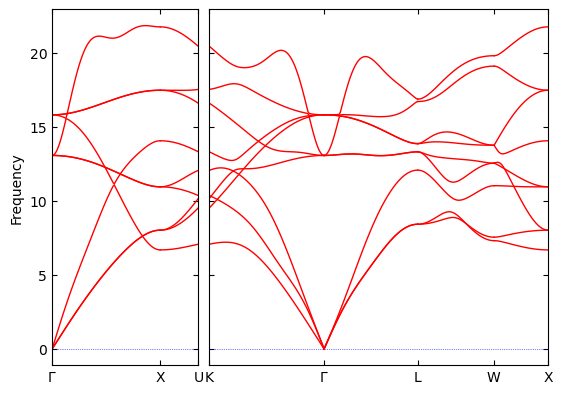

In [13]:
#pot_functions.set_calculator(calc)
phonon, fig = get_phonon_spectrum(bulk_strucs_dict['Li2O']['ase_atoms'], calc=calc)

# Dataset Tests

## create analysis_data

In [ ]:
mlp_f = []
mlp_e = []
pw_e = []
pw_f = []
diff_f = []
diff_e = []
gamma_list = []
gamma_mean_list = []

ase_list = []
dens_list = []
name_list = []

for i, (atoms, name, pw_energy, pw_forces) in enumerate(
    zip(strucs_all['ase_atoms'],
        strucs_all['name'],
        strucs_all['energy_corrected'],
        strucs_all['forces'])):

    struc = atoms.copy()
    struc.calc = calc

    nat = len(struc)

    ############################
    ###### general stuff #######
    ############################

    mass = struc.get_masses().sum()
    vol = struc.get_volume()

    dens = (mass * _amu) / (vol * 1e-27)
    dens_list.append(dens)

    struc_save = struc.copy()
    struc_save.calc = None

    ase_list.append(struc_save)
    name_list.append(name)

    ############################
    ##### Energies & Gamma #####
    ############################

    mlp_energy = struc.get_potential_energy()
    mlp_energy_pa = mlp_energy / nat

    pw_energy_pa = pw_energy / nat

    mlp_e.append(mlp_energy_pa)
    pw_e.append(pw_energy_pa)

    diff_e.append(1000 * (mlp_energy_pa - pw_energy_pa) )

    gamma = np.asarray(calc.results["gamma"])

    gamma_list.append(gamma.copy())
    gamma_mean_list.append(gamma.mean())

    ############################
    ########## Forces ########## 
    ############################

    pw_forces = np.asarray(pw_forces)
    mlp_forces = struc.get_forces()

    pw_norm = np.linalg.norm(pw_forces, axis=1)
    mlp_norm = np.linalg.norm(mlp_forces, axis=1)

    pw_f.append(pw_norm)
    mlp_f.append(mlp_norm)

    diff_f.append(1000 * (mlp_norm - pw_norm) )



####################################################################
########## Save calcs as dictionary and save as pckl file ########## 
####################################################################

analysis_data = {
    'name': name_list,
    'ase_atoms': ase_list,
    'density': dens_list,
    'pw_e_pA': pw_e,
    'mlp_e_pA': mlp_e,
    'diff_e_pA': diff_e,
    'pw_f': pw_f,
    'mlp_f': mlp_f,
    'diff_f': diff_f,
    'gamma_i': gamma_list,
    'gamma_mean': gamma_mean_list
}

analysis_df = pd.DataFrame(analysis_data)

analysis_df.to_pickle( os.path.join(analysis_path, 'analysis.pckl.gzip'),
                       compression='gzip',protocol=4)

## convex hull

In [ ]:
adaptor = AseAtomsAdaptor()

entries = []
for doc in docs:
    atoms = adaptor.get_atoms(doc.structure)
    
    if doc.formula_pretty != 'LiO8':
        
        atoms.calc=calc
        energy = atoms.get_potential_energy()

        entries.append(
        PDEntry(
            composition=doc.structure.composition,
            energy=energy
        )
    )

#O2 reference
entries.append(PDEntry(composition='O2', energy=bulk_energies['O2']))
#Li reference
entries.append(PDEntry(composition='Li2', energy=bulk_energies['Li2']))

p_diag = PhaseDiagram(entries)

In [ ]:
plotter = PDPlotter(
    p_diag,
    backend="matplotlib",
    show_unstable=True,
)
ax = plotter.get_plot()

## plots

### Visualize a structure with colorcoding

In [ ]:

import matplotlib.pyplot as plt


fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")

sc = ax.scatter(
    coords[:, 0],  # x
    coords[:, 1],  # y
    coords[:, 2],  # z
    #c=test_diff,       # color according to force magnitude
    c=gamma_list,
    cmap="viridis",
    s=50
)

# Draw bonds
cutoff = 1.25

for i in range(len(coords)):
    for j in range(i + 1, len(coords)):
        distance = np.linalg.norm(coords[i] - coords[j])

        if distance < cutoff:
            ax.plot(
                [coords[i, 0], coords[j, 0]],
                [coords[i, 1], coords[j, 1]],
                [coords[i, 2], coords[j, 2]],
                linewidth=1,
                color="black"
            )


ax.set_xlabel("x (Å)")
ax.set_ylabel("y (Å)")
ax.set_zlabel("z (Å)")

# Colorbar showing force magnitude
cbar = fig.colorbar(sc, ax=ax)
cbar.set_label("Force magnitude")

plt.show()

# Binding Curves

## O2-molecule 

In [ ]:
monomer_dmp=[]

for i in range(0, 30):
    name = f"O2_noPBC_monomer_{i}_OUT"

    if name in analysis_data['name']:
        idx = analysis_data['name'].index(name)
        
        atoms = analysis_data['ase_atoms'][idx]
        coords = atoms.get_positions()
        #molecule = atoms[[0, 1]]

        distance = np.linalg.norm(coords[1]-coords[0])

        monomer_dmp.append([distance,
                         analysis_data['pw_e_pA'][idx],
                         analysis_data['mlp_e_pA'][idx],
                         analysis_data['mlp_e_pA'][idx]-analysis_data['pw_e_pA'][idx],
                         ]) #d ,pw, mlp, diff
        
monomer_dmp = np.array(monomer_dmp)
monomer_dmp = monomer_dmp[monomer_dmp[:, 0].argsort()]

plt.plot(monomer_dmp[:,0], monomer_dmp[:,1], 'o-', label="PW")
plt.plot(monomer_dmp[:,0], monomer_dmp[:,2], 'o-', label="MLP")
#plt.plot(monomer_dmp[:,0], monomer_dmp[:,3], 'o-', label="MLP-PW")

plt.xlabel("O–O distance (Å)")
plt.ylabel("Energy (eV/atom)")
plt.legend()
plt.show()

### BDC str-gen

In [ ]:

e_list = []
d_list=[]
f_list=[]
atoms_list=[]

atoms_init = Atoms('O2', positions=[[25, 25, 25], [25, 25, 26.23]], cell=[30,30,30], pbc=True)
#atoms_init.center(vacuum=10.0)

#atoms_init = read('/ccc160/akirsan/PhD/MLP/Li2O/str-gen/O2/vdw-PBC/str_0/OUT', format = 'espresso-out')

#atoms.set_calculator(test_calc)

step = 0.2
nsteps = 20

for i in range(nsteps):
    d = 1 + i * step
    atoms_init.positions[1, 2] = atoms_init.positions[0, 2] + d
    atoms=atoms_init.copy()
    #atoms_init.center(vacuum=20.0)
    atoms=atoms_init.copy()
    atoms.set_calculator(calc)
    atoms_list.append(atoms.copy())
    e = atoms.get_potential_energy()
    f = atoms.get_forces()
    e_list.append(e)
    d_list.append(d)
    f_list.append(np.linalg.norm(f))
    #print('distance, energy', d, e)
    #print('force', f)
'''
for i in range(10):
    d = 1.1 + i* 0.03
    atoms_init.positions[1, 2] = atoms_init.positions[0, 2] + d
    atoms=atoms_init.copy()
    #atoms_init.center(vacuum=20.0)
    atoms=atoms_init.copy()
    atoms.set_calculator(calc)
    atoms_list.append(atoms.copy())
    e = atoms.get_potential_energy()
    f = atoms.get_forces()
    e_list.append(e)
    d_list.append(d)
    f_list.append(np.linalg.norm(f))
    #print('distance, energy', d, e)
    #print('force', f)
'''


plt.plot(d_list, e_list)
#plt.plot(d_list, f_list)
#view(atoms_list, viewer='ngl')
#plt.show()

## O2-dimer

In [ ]:
dimer_dmp=[]


# 0 - 19 : | |
# 20 - 39 : x |
# 40 - 59 : -- -- 
# 60 - 79 : x -- 

for i in range(20, 40):
    name = f"O2_noPBC_dimer_{i}_OUT"

    if name in analysis_data['name']:
        idx = analysis_data['name'].index(name)
        
        atoms = analysis_data['ase_atoms'][idx]

        dimer1 = atoms[[0, 1]]
        dimer2 = atoms[[2, 3]]

        com1 = dimer1.get_center_of_mass()
        com2 = dimer2.get_center_of_mass()

        distance = np.linalg.norm(com1 - com2)

        dimer_dmp.append([distance,
                         analysis_data['pw_e_pA'][idx],
                         analysis_data['mlp_e_pA'][idx],
                         analysis_data['mlp_e_pA'][idx]-analysis_data['pw_e_pA'][idx],
                         ]) #d ,pw, mlp, diff
        
        #pw_dmp.append(analysis_data['pw_e_pA'][idx])
        #mlp_dmp.append(analysis_data['mlp_e_pA'][idx])

dimer_dmp = np.array(dimer_dmp)
#plt.plot(dimer_dmp[:,0], dimer_dmp[:,1], 'o-', label="PW")
#plt.plot(dimer_dmp[:,0], dimer_dmp[:,2], 'o-', label="MLP")
plt.plot(dimer_dmp[:,0], dimer_dmp[:,3], 'o-', label="MLP-PW")

plt.xlabel("O$_2$–O$_2$ distance (Å)")
plt.ylabel("Energy (eV/atom)")
plt.legend()
plt.show()

### Dimer str-gen

In [ ]:

e_list = []
d_list=[]
f_list=[]
atoms_list=[]

#atoms_init = Atoms('O4', positions=[[5, 5, 5], [5, 5, 6.225],[6, 5, 5], [6, 5, 6.225] ], cell=[30,30,30], pbc=True)

step = 0.2
nsteps = 20

####################
####### o o ########
####### | | ########
####### o o ########
####################
for i in range(nsteps):
    d = 1.2 + i * step
    #d = step
    atoms_init = Atoms('O4', positions=[[5, 5, 4.3875], [5, 5, 5.6125],[5, 5, 4.3875], [5, 5, 5.6125] ], cell=[30,30,30], pbc=True)
    atoms_init.positions[2,0] = atoms_init.positions[2, 0]+d
    atoms_init.positions[3,0] = atoms_init.positions[3, 0]+d
    atoms=atoms_init.copy()
    atoms.set_calculator(calc)
    atoms_list.append(atoms.copy())
    e = atoms.get_potential_energy()
    f = atoms.get_forces()
    e_list.append(e)
    d_list.append(d)
    #f_list.append(np.linalg.norm(f))
    #print('distance, energy', d, e)
    #print('force', f)
#plt.plot(d_list, e_list)
#plt.plot(d_list, f_list)
#view(atoms_list, viewer='ngl')

###################
######## o ########
###### x | ########
######## o ########
###################
for i in range(nsteps):
    d = 1.2 + i * step
    #d = step
    atoms_init = Atoms('O4', positions=[[5, 5, 4.3875], [5, 5, 5.6125],[5, 4.3875, 5], [5, 5.6125, 5] ], cell=[30,30,30], pbc=True)
    atoms_init.positions[2,0] = atoms_init.positions[2, 0]+d
    atoms_init.positions[3,0] = atoms_init.positions[3, 0]+d
    atoms=atoms_init.copy()
    atoms_list.append(atoms.copy())

    
##################
##################
#### o-o o-o #####
##################
##################
for i in range(nsteps):
    d = 2.4 + i * step
    #d = step
    atoms_init = Atoms('O4', positions=[[4.3875, 5, 5], [5.6125, 5, 5],[4.3875, 5, 5], [5.6125, 5, 5] ], cell=[30,30,30], pbc=True)
    atoms_init.positions[2,0] = atoms_init.positions[2, 0]+d
    atoms_init.positions[3,0] = atoms_init.positions[3, 0]+d
    atoms=atoms_init.copy()
    atoms_list.append(atoms.copy())

###################
######## o ########
#### o-o | ########
######## o ########
###################
for i in range(nsteps):
    d = 1.4 + i * step
    #d = step
    atoms_init = Atoms('O4', positions=[[5, 5, 4.3875], [5, 5, 5.6125],[4.3875, 5, 5], [5.6125, 5, 5] ], cell=[30,30,30], pbc=True)
    atoms_init.positions[2,0] = atoms_init.positions[2, 0]+d
    atoms_init.positions[3,0] = atoms_init.positions[3, 0]+d
    atoms=atoms_init.copy()
    atoms_list.append(atoms.copy())

###################
######## o ########
#### o-o | ########
######## o ########
###################
for i in range(nsteps):
    d = 1.4 + i * step
    #d = step
    atoms_init = Atoms('O4', positions=[[5, 5, 4.3875], [5, 5, 5.6125],[4.3875, 5, 5], [5.6125, 5, 5] ], cell=[30,30,30], pbc=True)
    atoms_init.positions[2,0] = atoms_init.positions[2, 0]+d
    atoms_init.positions[3,0] = atoms_init.positions[3, 0]+d
    atoms=atoms_init.copy()
    atoms_list.append(atoms.copy())




#view(atoms_list, viewer='ngl')

In [ ]:
en_list = []
di_list=[]
fo_list=[]
atoms_list=[]

#atoms_init = Atoms('O4', positions=[[5, 5, 5], [5, 5, 6.225],[6, 5, 5], [6, 5, 6.225] ], cell=[30,30,30], pbc=True)

step = 0.2
nsteps = 20
for i in range(nsteps):
    ###################
    ### change this ###
    ###################
    
    d = 1.2 + i * step
    #d = step
    atoms_init = Atoms('O4', positions=[[5, 5, 4.3875], [5, 5, 5.6125],[5, 4.3875, 5], [5, 5.6125, 5] ], cell=[30,30,30], pbc=True)
    atoms_init.positions[2,0] = atoms_init.positions[2, 0]+d
    atoms_init.positions[3,0] = atoms_init.positions[3, 0]+d
    atoms=atoms_init.copy()
    atoms.set_calculator(calc)
    atoms_list.append(atoms.copy())
    
    ###################
    ###################
    ###################
    
    
    en_list.append(atoms.get_potential_energy())
    di_list.append(d)


plt.plot(di_list, en_list)

## Li2O

In [ ]:
strucs=['li2o']

alat_list=[]
energy_corr_list=[]

for struc in strucs:
    test_dir = f"/ccc160/akirsan/PhD/MLP/Li2O/binding-curves/{struc}/fit/"
    x = []
    xd = []
    y = []
    yd = []
    dummy1=[]
    x_ref = []
    y_ref = []


######   
    for file in os.listdir(test_dir):
        fpath = os.path.join(test_dir, file)
        
        if fnmatch.fnmatch(file, 'OUT*'):
            structure = read(fpath, format = 'espresso-out')
            structure.set_calculator(calc)
            energy = structure.get_potential_energy()
            #forces = structure.get_forces()
            #gamma = structure.get_gamma()
            elems = structure.get_chemical_symbols()
            elem_dict = Counter(elems)
            n_units = elem_dict['O']
            ref_e = (2 * ref_energies['Li'] + ref_energies['O']) * n_units
            
            corr_e = (energy + ref_e)
            energy_corr_list.append(corr_e/Rydberg)
            
            vol_per_unit = structure.get_volume() / n_units
            energy_per_unit = corr_e / n_units
            #xd.append(vol_per_unit)
            
            alat=float(file.replace('OUT.',''))
            alat_list.append(alat)
            alat_angstrom=alat*0.529177
            
            xd.append(alat_angstrom)
            yd.append(energy_per_unit)

        else:
            continue
######                    
    for k in range(len(xd)):
        dummy2=[xd[k], yd[k]]
        dummy1.append(dummy2)
    dummy1.sort(key=lambda tup: tup[0])
    for j in range(len(dummy1)):
        x.append(dummy1[j][0])
        y.append(dummy1[j][1])

    x_ref = []
    y_ref = []

    x_ref = np.loadtxt(f"/ccc160/akirsan/PhD/MLP/Li2O/binding-curves/{struc}/fit/plot/out.dat", usecols=0)
    y_ref = np.loadtxt(f"/ccc160/akirsan/PhD/MLP/Li2O/binding-curves/{struc}/fit/plot/out.dat", usecols=1)

    #E_diff= y-y_ref
    
    #x_ref.append(x_ref0)
    #y_ref.append(y_ref0)
    #plt.title(f"{struc}")
    plt.plot(x, y_ref, label = f"{struc}",linewidth=2)
    plt.plot(x, y,'k:', linewidth=1.8, color='green', label = pot_name)
    #plt.xlabel("Volume per Li$_2$O unit / $\AA ^3$")
    plt.xlabel("Lattice constant / $\AA $")
    plt.ylabel("Energy per Li$_2$O unit / eV")
    plt.legend()
    plt.ylim((-830.84, -830.8))
    plt.xlim((4.5, 4.7))
    plt.ticklabel_format(axis='y', style='plain', useOffset=False)

### Li2O alat

In [ ]:
data = '/ccc160/bmeyer/work/project-battery/Li2O-bulk/fcc.pbe+D3surf-mod/elast-const/B-bulk-modulus/vol.k08/'
#alat = np.loadtxt(f"{data}", usecols = 0, skiprows=1, max_rows=14)
#PE = np.loadtxt(f"{data}", usecols = 1, skiprows=1, max_rows=14)

alat_list=[]
energy_corr_list=[]

for file in os.listdir(data):
    fpath = os.path.join(data, file)
        
    if fnmatch.fnmatch(file, 'OUT*'):
        structure = read(fpath, format = 'espresso-out')
        structure.set_calculator(calc)
        energy = structure.get_potential_energy()
        elems = structure.get_chemical_symbols()
        elem_dict = Counter(elems)
        ref_e = elem_dict['Li']*ref_energies['Li'] + elem_dict['O']*ref_energies['O']
            
        corr_e = (energy + ref_e)
        energy_corr_list.append(corr_e/Rydberg)
        alat=float(file.replace('OUT.',''))
        alat_list.append(alat)

fit_coef = np.polyfit(alat_list, energy_corr_list, 3) # f = coef0*x**3 + coef1*x**2 + coef2*x +coef3
fit = np.poly1d(fit_coef)

df = np.polyder(fit)    # f' -> quadratic: f' = 3*coef0x**2 + 2*coef1*x + coef2

a_df = 3*fit_coef[0]
b_df = 2*fit_coef[1]
c_df = fit_coef[2]

disc_df = np.sqrt(b_df**2 - 4*a_df*c_df)

x_1 = (-b_df + disc_df)/(2*a_df) # extremum 1 of fit
y_1 = fit(x_1)
x_2 = (-b_df - disc_df)/(2*a_df) # extremum 2 of fit
y_2 = fit(x_2)

ddf = np.polyder(df)  # f'' -> linear:   f''= 6*coef0*x + 2*coef1
ddfit = np.poly1d(ddf)

bmod_1 = ddfit(x_1)*0.5  # bmod from Bernds script, 0.5*(d^2 E/ d a^2 |_a0)
bmod_2 = ddfit(x_2)*0.5

B_1 = (2*bmod_1)/(9*x_1)*1.47108*10**4 # B in GPa
B_2 = (2*bmod_2)/(9*x_2)*1.47108*10**4

print(f"Extrema 1: x = {x_1}, y = {y_1}, bmod = {bmod_1}, B = {B_1}")
print(f"Extrema 2: x = {x_2}, y = {y_2}, bmod = {bmod_2}, B = {B_2}")

print(f"Lattice constant = {x_1*0.529177} Angstrom")

## Li-Metal

In [ ]:
#strucs=[ 'bcc', 'fcc', 'cubicP']
strucs=['bcc']

for struc in strucs:
    test_dir = f"/ccc160/akirsan/PhD/MLP/Li2O/binding-curves/li-metal/{struc}/fit/"
    x = []
    xd = []
    y = []
    y_2 = []
    yd = []
    yd_2 = []
    dummy1=[]
    x_ref = []
    y_ref = []

######   
    for file in os.listdir(test_dir):
        fpath = os.path.join(test_dir, file)
        
        if fnmatch.fnmatch(file, 'OUT*'):
            structure = read(fpath, format = 'espresso-out')
            structure.set_calculator(calc)
            energy = structure.get_potential_energy()
            #forces = structure.get_forces()
            #gamma = structure.get_gamma()
            elems = structure.get_chemical_symbols()
            elem_dict = Counter(elems)
            n_units = elem_dict['Li']
            ref_e = ref_energies['Li'] * n_units
            corr_e = (energy + ref_e)
            vol_per_unit = structure.get_volume() / n_units
            energy_per_unit = corr_e / n_units
            alat=float(file.replace('OUT.',''))
            alat_angstrom=alat*0.529177
            
            xd.append(alat_angstrom)
            yd.append(energy_per_unit)
            #print(alat, energy)
        else:
            continue
######                    
    for k in range(len(xd)):
        dummy2=[xd[k], yd[k]]
        dummy1.append(dummy2)
    dummy1.sort(key=lambda tup: tup[0])
    for j in range(len(dummy1)):
        x.append(dummy1[j][0])
        y.append(dummy1[j][1])

    x_ref = []
    y_ref = []

    x_ref = np.loadtxt(f"/ccc160/akirsan/PhD/MLP/Li2O/binding-curves/li-metal/{struc}/fit/plot/out.dat", usecols=0)
    y_ref = np.loadtxt(f"/ccc160/akirsan/PhD/MLP/Li2O/binding-curves/li-metal/{struc}/fit/plot/out.dat", usecols=1)

    #E_diff= y-y_ref
    
    y_arr = np.array(y)
    
    plt.plot(x, y_ref, label = "Li-metal bcc",linewidth=2)
    plt.plot(x, y_arr,'k:', linewidth=1.8, color='green', label = pot_name)
    plt.ylim((-195.346, -195.33))
    plt.xlim((3.35, 3.5))
    plt.xlabel("Lattice constant / $\AA $")
    plt.ylabel("Energy per Li atom / eV")
    plt.legend()
    plt.ticklabel_format(axis='y', style='plain', useOffset=False)
    plt.tight_layout()

In [ ]:
#strucs=[ 'bcc', 'fcc', 'cubicP']
strucs=['fcc']

for struc in strucs:
    test_dir = f"/ccc160/akirsan/PhD/MLP/Li2O/binding-curves/li-metal/{struc}/fit/"
    x = []
    xd = []
    y = []
    y_2 = []
    yd = []
    yd_2 = []
    dummy1=[]
    x_ref = []
    y_ref = []

######   
    for file in os.listdir(test_dir):
        fpath = os.path.join(test_dir, file)
        
        if fnmatch.fnmatch(file, 'OUT*'):
            structure = read(fpath, format = 'espresso-out')
            structure.set_calculator(calc)
            energy = structure.get_potential_energy()
            #forces = structure.get_forces()
            #gamma = structure.get_gamma()
            elems = structure.get_chemical_symbols()
            elem_dict = Counter(elems)
            n_units = elem_dict['Li']
            ref_e = ref_energies['Li'] * n_units
            corr_e = (energy + ref_e)
            vol_per_unit = structure.get_volume() / n_units
            energy_per_unit = corr_e / n_units
            alat=float(file.replace('OUT.',''))
            alat_angstrom=alat*0.529177
            
            xd.append(alat_angstrom)
            yd.append(energy_per_unit)
            #print(alat, energy)
        else:
            continue
######                    
    for k in range(len(xd)):
        dummy2=[xd[k], yd[k]]
        dummy1.append(dummy2)
    dummy1.sort(key=lambda tup: tup[0])
    for j in range(len(dummy1)):
        x.append(dummy1[j][0])
        y.append(dummy1[j][1])

    x_ref = []
    y_ref = []

    x_ref = np.loadtxt(f"/ccc160/akirsan/PhD/MLP/Li2O/binding-curves/li-metal/{struc}/fit/plot/out.dat", usecols=0)
    y_ref = np.loadtxt(f"/ccc160/akirsan/PhD/MLP/Li2O/binding-curves/li-metal/{struc}/fit/plot/out.dat", usecols=1)

    #E_diff= y-y_ref
    
    y_arr = np.array(y)
    
    plt.plot(x, y_ref, label = "Li-metal bcc",linewidth=2)
    plt.plot(x, y_arr,'k:', linewidth=1.8, color='green', label = pot_name)
    plt.ylim((-195.350, -195.335))
    plt.xlim((4.2, 4.4))
    plt.xlabel("Lattice constant / $\AA $")
    plt.ylabel("Energy per Li atom / eV")
    plt.legend()
    plt.ticklabel_format(axis='y', style='plain', useOffset=False)
    plt.tight_layout()

# MISC

In [ ]:
scfs_dir = '/ccc160/akirsan/PhD/MLP/Li2O/str-gen/O2/own/monomer'

for i in range(len(atoms_list)):
    struc = atoms_list[i]
    #struc.wrap()
    input_data = {
                    'calculation' : 'scf',
                    'restart_mode' : 'from_scratch',
                    'pseudo_dir' : '/ccc160/bmeyer/pot.pwscf/',
                    'outdir' : './',
                    'prefix' : f"str_monomer_{i}",
                    'etot_conv_thr' : 1.e-5,
                    'tprnfor' : True,
                    'forc_conv_thr' : 1.e-5,
                    'ecutwfc' :30.0,
                    'ecutrho' :120.0,
                    'occupations' : 'smearing',
                    'mixing_mode' : 'plain',
                    'smearing' : 'gauss',
                    'degauss' : 0.01,
                    'vdw_corr' : 'D3-ext',
                    'london_rcut' : 100,
                    'diagonalization' : 'david',
                    'electron_maxstep' : 300,
                    'conv_thr' :1.0e-7,
                    'mixing_beta' : 0.2,
                    'kpts' : (1, 1, 1),
                    'koffset' : (0, 0, 0),
                    }
                
    pseudopotentials = {
                    'O' : 'O.uspp736.pbe.UPF',
                    }

    scf_dir = os.path.join(scfs_dir, f"str_monomer_{i}")
    input_file_path = os.path.join(scf_dir, "INP")
    run(f"mkdir {scf_dir}")

                
    with open(input_file_path, mode = 'w') as f:
                write(f, struc, format  = 'espresso-in', input_data=input_data, \
                pseudopotentials=pseudopotentials,\
                kpts=input_data['kpts'], koffset=input_data['koffset'])


In [ ]:

scfs_dir='/ccc160/akirsan/PhD/MLP/Li2O/str-gen/O2/own/cpmd/scfs-trimer'

traj_path = '/ccc160/akirsan/PhD/MLP/Li2O/str-gen/O2/own/cpmd/4.md/trimer/'
setup = traj_path.replace("/ccc160/akirsan/PhD/MLP/Li2O/str-gen/O2/own/cpmd/4.md/", "")
setup = setup.replace('/','_')
setup = setup.rstrip("_")
traj = read(os.path.join(traj_path,'TRAJEC.xyz'), format ='xyz', index="::10")

i=0
for struc in traj:
    i=i+1
    struc.set_pbc(True)
    struc.set_cell([7.5,7.5,7.5])
    struc.wrap()
    input_data = {
                    'calculation' : 'scf',
                    'restart_mode' : 'from_scratch',
                    'pseudo_dir' : '/ccc160/bmeyer/pot.pwscf/',
                    'outdir' : './',
                    'prefix' : f"{setup}_{i}",
                    'etot_conv_thr' : 1.e-5,
                    'tprnfor' : True,
                    'forc_conv_thr' : 1.e-5,
                    'ecutwfc' :30.0,
                    'ecutrho' :120.0,
                    'occupations' : 'smearing',
                    'mixing_mode' : 'plain',
                    'smearing' : 'gauss',
                    'degauss' : 0.01,
                    'vdw_corr' : 'D3-ext',
                    'london_rcut' : 100,
                    'diagonalization' : 'david',
                    'electron_maxstep' : 300,
                    'conv_thr' :1.0e-7,
                    'mixing_beta' : 0.2,
                    'kpts' : (1, 1, 1),
                    'koffset' : (0, 0, 0),
                    }
                
    pseudopotentials = {
                    'O' : 'O.uspp736.pbe.UPF',
                    }

    scf_dir = os.path.join(scfs_dir, f"{setup}_{i}")
    input_file_path = os.path.join(scf_dir, "INP")
    run(f"mkdir {scf_dir}")

                
    with open(input_file_path, mode = 'w') as f:
                write(f, struc, format  = 'espresso-in', input_data=input_data, \
                pseudopotentials=pseudopotentials,\
                kpts=input_data['kpts'], koffset=input_data['koffset'])



# Energy + strain curve graph

/tmp/ipykernel_22496/696877130.py:26: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


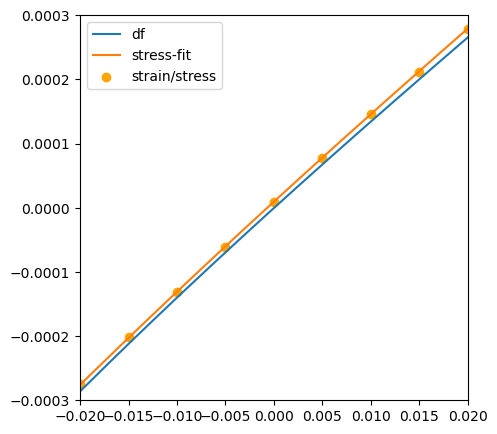

In [338]:
strain_energy = np.loadtxt('/ccc160/akirsan/PhD/MLP/Li2O/ref-energies/Li2O-pwscf/elastic/strain-stress/C11/no-relax/result.out')
strain_stress = np.loadtxt('/ccc160/akirsan/PhD/MLP/Li2O/ref-energies/Li2O-pwscf/elastic/strain-stress/C11/no-relax/strain-stress.dat')



fit_coef_stress = np.polyfit(strain_stress[:,0], strain_stress[:,1], 5)
fit_stress = np.poly1d(fit_coef_stress)
y_stress=fit_stress(x_ddf)

fit_coef_energy = np.polyfit(strain_energy[:,0], strain_energy[:,1], 4)
fit_energy = np.poly1d(fit_coef_energy)

df_energy = np.polyder(fit_energy)   
ddf_energy = np.polyder(df_energy)

x_ddf = np.linspace(-0.05, 0.05, 500)
y_df = df_energy(x_ddf)
y_ddf = ddf_energy(x_ddf)

y_energy_fit = fit_energy(x_ddf)

fig = plt.figure(figsize=(5,5))
ax = fig.subplots()
ax.ticklabel_format(axis='y', style='plain', useOffset=False)
#ax.ticklabel_format(axis='x', style='plain', useOffset=False)
ax.legend()
ax.set_xlim(-0.02, 0.02)
ax.set_ylim(-0.0003, 0.0003)
ax.plot(x_ddf, 1/659.8436*y_df, label='df')
ax.plot(x_ddf, -y_stress, label='stress-fit')
ax.scatter(strain_stress[:,0], -strain_stress[:,1], label='strain/stress', color='orange')
#ax.plot(x_ddf, y_energy_fit, label='ddf')
ax.legend()
plt.show()


In [339]:
fit_coef_energy

array([ 4.09663237e+01, -5.46819245e+00,  4.51455095e+00, -3.06733785e-04,
       -2.44259226e+02])

/tmp/ipykernel_22496/2737984299.py:35: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


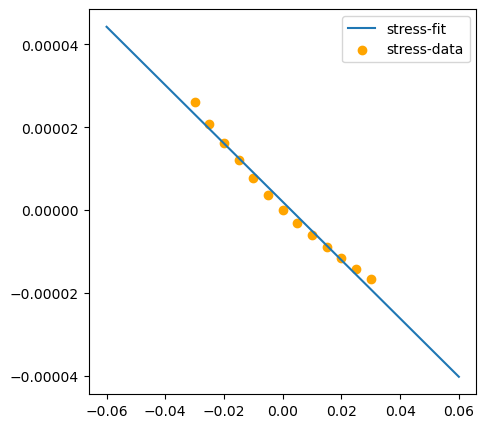

In [567]:
# Li2O2 c13


strain_energy = np.loadtxt('/ccc160/akirsan/PhD/MLP/Li2O/ref-energies/Li2O2-pwscf/elastic/C33/result.out')
strain_stress = np.loadtxt('/ccc160/akirsan/PhD/MLP/Li2O/ref-energies/Li2O2-pwscf/elastic/C13/strain-stress.dat') # for C13


fit_coef_stress = np.polyfit(strain_stress[:,0], strain_stress[:,1], 1) # for C13
fit_stress = np.poly1d(fit_coef_stress) # for C13




for i in range(len(strain_energy)):
    strain_energy[i][0] = 1-(strain_energy[i][0]/2.4335)


fit_coef_energy = np.polyfit(strain_energy[:,0], strain_energy[:,1], 2)
fit_energy = np.poly1d(fit_coef_energy)

df_energy = np.polyder(fit_energy)   
ddf_energy = np.polyder(df_energy)

x_plot = np.linspace(-0.06, 0.06, 500)
y_energy_fit = fit_energy(x_plot)
y_df = df_energy(x_plot)
y_ddf = ddf_energy(x_plot)
y_stress=fit_stress(x_plot) # for C13


fig = plt.figure(figsize=(5,5))
ax = fig.subplots()
ax.ticklabel_format(axis='y', style='plain', useOffset=False)

ax.legend()
#ax.set_xlim(-0.02, 0.02)
#ax.set_ylim(-0.0003, 0.0003)

#ax.plot(x_plot, 1/441.6269*y_df, label='df')
#ax.plot(x_plot, y_energy_fit, label='energy-fit')

ax.plot(x_plot, y_stress, label='stress-fit') # for C13
ax.scatter(strain_stress[:,0], strain_stress[:,1], label='stress-data', color='orange') # for C13

ax.legend()
plt.show()

In [569]:
#(fit_coef_energy[0]*2)/441.6269 * Ry_bohr3_to_GPa
-fit_coef_stress[0]* Ry_bohr3_to_GPa

10.362222857142857

# TEST

In [63]:
structure = Structure.from_ase_atoms(bulk_strucs_dict['Li2O2']['ase_atoms'])
sga = SpacegroupAnalyzer(structure)
conventional = sga.get_conventional_standard_structure() # convert structure to conventional cell
slabgen = SlabGenerator(
conventional,
miller_index=(0, 0, 1),
min_slab_size=2,
min_vacuum_size=1,
center_slab=False,
in_unit_planes = True,
 max_normal_search = 1
)
slabs = slabgen.get_slabs()
slab = slabs[0]
surf = slab.to_ase_atoms()
surf.center(vacuum=0, axis=2)
#surf = surf.repeat((2, 2, 1))

surf.calc=calc
surfs_atoms=[]
energies = []
write('/ccc160/akirsan/PhD/struc.dat', surf, format = 'lammps-data', masses=True)

In [64]:
layers = get_layers(surf)
match=find_matching_layers(surf, layers)
z = len(layers) * match[1] / match[0]
surf=surf.repeat((2,2,1))
vac = 15
cell = surf.cell
cell[2] = cell[2] / np.linalg.norm(cell[2]) * (z+vac)
surf.set_cell(cell)


# INSPECT FUNCTIONS

In [235]:
import inspect
lines = inspect.getsource(find_stable_surface())
print(lines)

TypeError: find_stable_surface() missing 5 required positional arguments: 'atoms', 'h', 'k', 'l', and 'nrep'

In [425]:
lines = inspect.getsource(spg.get_symmetry_dataset)
print(lines)

def get_symmetry_dataset(
    cell: Cell,
    symprec=1e-5,
    angle_tolerance=-1.0,
    hall_number=0,
) -> SpglibDataset | None:
    """Search symmetry dataset from an input cell.

    Parameters
    ----------
    cell, symprec, angle_tolerance:
        See :func:`get_symmetry`.
    hall_number : int
        If a serial number of Hall symbol (>0) is given, the database
        corresponding to the Hall symbol is made.

        The mapping from Hall symbols to a space-group-type is the many-to-one mapping.
        Without specifying this
        option (i.e., in the case of ``hall_number=0``), always the first one
        (the smallest serial number corresponding to the space-group-type in
        [list of space groups (Seto's web site)](https://yseto.net/en/sg/sg1))
        among possible choices and settings is chosen as default. This
        argument is useful when the other choice (or setting) is expected to
        be hooked.

        This affects to the obtained values of `int